# Assignment 3: Transformer fine-tuning

Authors: Julia Wlodarska (S5965780), Lara van den Broek (S5883288), Tessa van Staalduinen (S5999286)

This notebook implements the fine-tuning of a pretrained DistilBERT model for 4-way news topic classification on the AG News dataset.

The notebook includes data preprocessing, tokenization, model training, and evaluation using accuracy and macro-averaged F1 score. Additionally, learning curves, a confusion matrix, and error analysis are provided to assess model performance and identify common failure modes. Finally, the model outputs 20 example errors.

Note: Model was trained on Google Colab (T4 GPU)

# Imports

In [ ]:
# Standard library
import random
import sys
sys.path.append("..")

# Third-party libraries
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Hyperparameters

In [ ]:
TRANSFORMER_CONFIG = {
    "model_name": "distilbert-base-uncased",
    "max_len": 64,
    "batch_size": 32,
    "lr": 2e-5,
    "epochs": 4,
    "patience": 2,
    "warmup_ratio": 0.1,
    "num_classes": 4,
    "weight_decay": 0.01,
}

## Load the data and split

In [ ]:
class AGNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
# Dataset loading
# Classes: World (1), Sports (2), Business (3), Sci/Tech (4)
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
df_train = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["train"], lines=True)
test_dataset = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["test"], lines=True)

# Map integers to class names
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

# Train-dev splits (10% of training data as a development set)
train_dataset, dev_dataset = train_test_split(
    df_train,
    test_size=0.1,
    random_state=42,
    stratify=df_train["label"]
)

print(f"Training split: {len(train_dataset)} examples")
print(f"Development split: {len(dev_dataset)} examples")
print(f"Testing split: {len(test_dataset)} examples")

# Combine titles and descriptions
X_train = train_dataset["title"] + " " + train_dataset["description"]
y_train = train_dataset["label"]

X_dev = dev_dataset["title"] + " " + dev_dataset["description"]
y_dev = dev_dataset["label"]

X_test = test_dataset["title"] + " " + test_dataset["description"]
y_test = test_dataset["label"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Training split: 108000 examples
Development split: 12000 examples
Testing split: 7600 examples


# Tokenizer and model

In [ ]:
# Hugging Face tokenizer for DistilBERT
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_CONFIG["model_name"])

model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_CONFIG["model_name"],
    num_labels=TRANSFORMER_CONFIG["num_classes"],
)

model = model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Tokenize the texts

In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=TRANSFORMER_CONFIG["max_len"],
)

dev_encodings = tokenizer(
    X_dev.tolist(),
    truncation=True,
    padding=True,
    max_length=TRANSFORMER_CONFIG["max_len"],
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=TRANSFORMER_CONFIG["max_len"],
)

def to_zero_indexed(series):
    return (series - 1).tolist()

train_labels_0 = to_zero_indexed(y_train)
dev_labels_0   = to_zero_indexed(y_dev)
test_labels_0  = to_zero_indexed(y_test)

tokenized_train = AGNewsDataset(train_encodings, train_labels_0)
tokenized_dev   = AGNewsDataset(dev_encodings, dev_labels_0)
tokenized_test  = AGNewsDataset(test_encodings, test_labels_0)

# Training

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=TRANSFORMER_CONFIG["lr"],
    per_device_train_batch_size=TRANSFORMER_CONFIG["batch_size"],
    per_device_eval_batch_size=TRANSFORMER_CONFIG["batch_size"],
    num_train_epochs=TRANSFORMER_CONFIG["epochs"],
    weight_decay=TRANSFORMER_CONFIG["weight_decay"],
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()
trainer.save_model("./distilbert_agnews")
tokenizer.save_pretrained("./distilbert_agnews")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.236292,0.177515,0.939500,0.939546
2,0.140565,0.178335,0.944583,0.944578
3,0.097606,0.188724,0.945750,0.945700
4,0.068570,0.211892,0.944833,0.944812


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_agnews/tokenizer_config.json',
 './distilbert_agnews/tokenizer.json')

# Evaluation

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation Results: {eval_results}")

predictions = trainer.predict(tokenized_test)
preds  = np.argmax(predictions.predictions, axis=-1)
test_labels_list = predictions.label_ids

Evaluation Results: {'eval_loss': 0.1887160986661911, 'eval_accuracy': 0.94575, 'eval_macro_f1': 0.9456995288815351, 'eval_runtime': 21.8274, 'eval_samples_per_second': 549.769, 'eval_steps_per_second': 17.18, 'epoch': 4.0}


# Confusion matrix

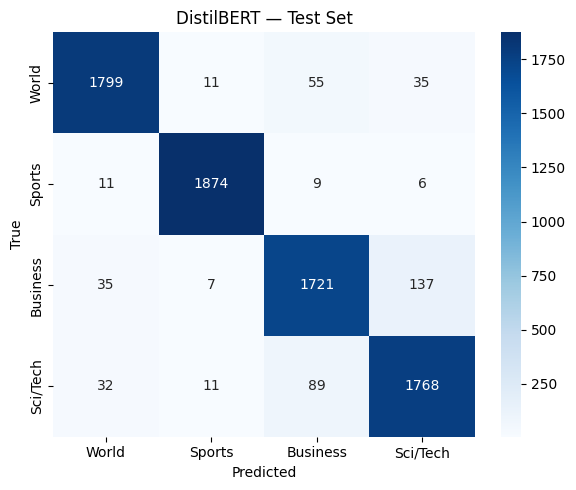

In [ ]:
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

cm = confusion_matrix(test_labels_list, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("DistilBERT — Test Set")
plt.tight_layout()
plt.show()

# Learning curves

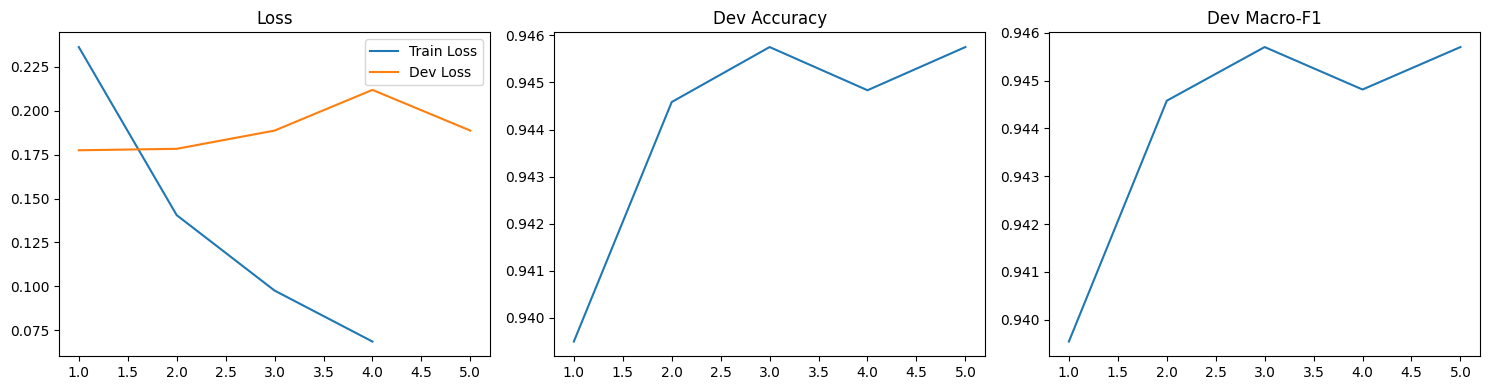

In [ ]:
log_history = trainer.state.log_history

train_loss = [x["loss"]          for x in log_history if "loss" in x and "eval_loss" not in x]
eval_loss  = [x["eval_loss"]     for x in log_history if "eval_loss" in x]
eval_acc   = [x["eval_accuracy"] for x in log_history if "eval_accuracy" in x]
eval_f1    = [x["eval_macro_f1"] for x in log_history if "eval_macro_f1" in x]
epochs     = range(1, len(eval_loss) + 1)

train_epochs = range(1, len(train_loss) + 1)
eval_epochs  = range(1, len(eval_loss)  + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_epochs, train_loss, label="Train Loss")
axes[0].plot(eval_epochs, eval_loss,  label="Dev Loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs, eval_acc)
axes[1].set_title("Dev Accuracy")

axes[2].plot(epochs, eval_f1)
axes[2].set_title("Dev Macro-F1")

plt.tight_layout()
plt.show()

# Test set evaluation

In [ ]:
test_results = trainer.predict(tokenized_test)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels_list = test_results.label_ids

test_acc = accuracy_score(test_labels_list, test_preds)
test_f1  = f1_score(test_labels_list, test_preds, average="macro")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")

Test Accuracy: 0.9424
Test Macro-F1: 0.9424


# Error analysis

In [ ]:
def collect_errors(texts, true_labels, pred_labels, label_map, n=20):
    """Return a DataFrame of misclassified examples."""
    texts_list = texts.tolist() if hasattr(texts, "tolist") else list(texts)
    rows = []
    for i, (true, pred) in enumerate(zip(true_labels, pred_labels)):
        if true != pred:
            rows.append({
                "text":       texts_list[i],
                "true_label": label_map[true + 1],   # back to 1-indexed for readability
                "pred_label": label_map[pred + 1],
            })
    return pd.DataFrame(rows).head(n)

error_df = collect_errors(X_test, test_labels_list, test_preds, label_map, n=20)
print(f"\nFirst 20 misclassified examples (DistilBERT):\n")
pd.set_option("display.max_colwidth", 120)
print(error_df.to_string(index=False))


First 20 misclassified examples (DistilBERT):

                                                                                                                                                                                                                                                                                                                                                                  text true_label pred_label
Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a new level of public participation. But this isn't the case.   Sci/Tech   Business
                                                                                                                                                                                              